In [88]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from gensim.models import KeyedVectors, Word2Vec
from pathlib import Path
from datetime import datetime
from collections import Counter
import json
from sklearn.model_selection import GridSearchCV

In [89]:
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

try:
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')
except:
    nltk.download('stopwords')
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')

In [90]:
train_bodies = pd.read_csv('./data/train_bodies.csv')
test_bodies = pd.read_csv('./data/test_bodies.csv')

train_stances = pd.read_csv('./data/train_stances.csv')
test_stances = pd.read_csv('./data/test_stances_unlebeledb.csv') 

In [91]:
train_stances.head(3)

,Unnamed: 0,Body ID,Headline,Stance,Headline1,Headline2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...


# Проведем предобработку данных

## Объединим данные

In [92]:
train_data = train_stances.merge(train_bodies, on='Body ID', how='left')
test_data = test_stances.merge(test_bodies, on='Body ID', how='left')

In [93]:
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...


## Проведем предобработку русского языка

In [94]:
def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]
    
    return ' '.join(words)

def preprocess_text_en(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in english_stopwords and len(word) > 2]
    
    return ' '.join(words)


## Обработка заголовков и текстов

In [95]:
eng_data = pd.read_csv("./data/eng_data")

eng_data = eng_data.rename(columns={'title': 'Headline', 'text': 'articleBody'})

eng_data.sample(3)

,Headline,articleBody,label
13413,"After Jeb Tweets Pic Of His New Gun, His Pand...","Desperate times call for desperate measures, o...",0
23381,Malay set to be Singapore's first woman presid...,SINGAPORE (Reuters) - A former speaker of Sing...,1
3880,North Korea defiant over U.N. sanctions as Tru...,SEOUL/WASHINGTON (Reuters) - North Korea displ...,1


In [96]:
train_data['headline_clean'] = train_data['Headline'].apply(preprocess_text)
train_data['body_clean'] = train_data['articleBody'].apply(preprocess_text)

test_data['headline_clean'] = test_data['Headline'].apply(preprocess_text)
test_data['body_clean'] = test_data['articleBody'].apply(preprocess_text)

eng_data['headline_clean'] = eng_data['Headline'].apply(preprocess_text_en)
eng_data['body_clean'] = eng_data['articleBody'].apply(preprocess_text_en)

In [97]:
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean
16245,Abducted Swiss aid worker freed in Sudan's Darfur,KHARTOUM (Reuters) - A 72-year-old Swiss aid w...,1,abducted swiss aid worker freed sudan darfur,khartoum reuters year old swiss aid worker fre...
298,Is This Dem Senator Switching Parties? Calls O...,Rumors continue to swirl around West Virginia ...,0,dem senator switching parties calls nfl owners...,rumors continue swirl around west virginia sen...
7130,The Right’s Stupidity Forces Snopes To Debunk...,"Last week, President Obama made a historic tri...",0,right stupidity forces snopes debunk article o...,last week president obama made historic trip c...


## Создадим комбинированные признаки (заголовок + начало текста)

In [98]:
def combine_features(row):
    headline = row['headline_clean']
    body_words = row['body_clean'].split()
    body = ' '.join(body_words)
    return f"{headline} {body}"

In [99]:
train_data['combined_text'] = train_data.apply(combine_features, axis=1)
test_data['combined_text'] = test_data.apply(combine_features, axis=1)
eng_data['combined_text'] = eng_data.apply(combine_features, axis=1)

In [100]:
train_data = train_data[train_data['combined_text'].str.len() > 10].reset_index(drop=True)
test_data = test_data[test_data['combined_text'].str.len() > 10].reset_index(drop=True)
eng_data = eng_data[eng_data['combined_text'].str.len() > 10].reset_index(drop=True)

In [101]:
train_data['text_length'] = train_data['combined_text'].str.split().str.len()
print(f"\nСтатистика длины комбинированных текстов (в словах):")
print(train_data['text_length'].describe())

train_data_tf = train_data



Статистика длины комбинированных текстов (в словах):
count    4408.000000
mean      136.134528
std        69.050534
min         9.000000
25%       101.000000
50%       126.000000
75%       153.000000
max      1084.000000
Name: text_length, dtype: float64


In [102]:
train_data.iloc[0]

Unnamed: 0_x                                                      0
Body ID                                                           1
Headline          ['российский', 'бюджет', 'марте', 'недополучил...
Stance                                                        agree
Headline1         российский бюджет в марте недополучил более 30...
Headline2         российский бюджет март недополучать миллиард р...
Unnamed: 0_y                                                      0
articleBody       Разница между ожидаемыми по итогам марта нефте...
articleBody1      разница ожидаемыми итогам марта нефтегазовыми ...
articleBody2      разница ожидать итог март нефтегазовый доход ф...
headline_clean    российский бюджет марте недополучил миллиардов...
body_clean        разница ожидаемыми итогам марта нефтегазовыми ...
combined_text     российский бюджет марте недополучил миллиардов...
text_length                                                      73
Name: 0, dtype: object

## Подготовим целевую переменную
---
где:
* Реальная новость - 1
* Фейк - 0

In [103]:
label_mapping = {'agree': 1, 'disagree': 0}

train_data['label'] = train_data['Stance'].map(label_mapping)
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


In [104]:
train_data_tf['label'] = train_data_tf['Stance'].map(label_mapping)
train_data_tf.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


### Удалим все лишнее

In [105]:
train_data.drop(columns=["Unnamed: 0_x", "Body ID", "Headline", "Headline1", "Headline2", "Unnamed: 0_y", "articleBody",
                         "articleBody1", "articleBody2", "Stance"], inplace=True)

In [106]:
train_data.sample(3)

,headline_clean,body_clean,combined_text,text_length,label
941,лукашенко попросил россию выделить земли сибир...,президент белоруссии направил официальный запр...,лукашенко попросил россию выделить земли сибир...,137,0
3732,бывшего осветителя московской филармонии котор...,бывший осветитель московской филармонии станис...,бывшего осветителя московской филармонии котор...,95,1
4053,конрад карлович лихтенштейн возведён должность...,торжественная инаугурация завершилась столице ...,конрад карлович лихтенштейн возведён должность...,176,0


# Word2Vec

## Загрузим эмбеддинги

In [107]:
sentences = [text.split() for text in train_data['body_clean']] + [text.split() for text in train_data['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

## Функция для получения усреднённого вектора

In [108]:
def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    if not vecs:
        return np.zeros(kv_model.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

## Соберем признаки: headline_vec, body_vec, косинусная близость

In [109]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

def jaccard(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A and not B:
        return 0.0
    return len(A & B) / max(1, len(A | B))

def overlap_ratio(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A:
        return 0.0
    return len(A & B) / len(A)

def elementwise_stats(h_vec, b_vec):
    diff = np.abs(h_vec - b_vec)              
    prod = h_vec * b_vec                      
    l2 = np.linalg.norm(h_vec - b_vec)        
    return diff, prod, l2

def build_features(df, kv, max_len=150):
    H, B, COS, JAC, OVR, L2, DIFF, PROD = [], [], [], [], [], [], [], []
    for i, row in df.iterrows():
        htoks = row['headline_clean'].split()[:max_len]
        btoks = row['body_clean'].split()[:max_len]

        h_vec = doc_vector(htoks, kv)
        b_vec = doc_vector(btoks, kv)

        H.append(h_vec); B.append(b_vec)

        COS.append(cosine(h_vec, b_vec))
        JAC.append(jaccard(htoks, btoks))
        OVR.append(overlap_ratio(htoks, btoks))

        diff, prod, l2 = elementwise_stats(h_vec, b_vec)
        DIFF.append(diff); PROD.append(prod); L2.append(l2)

    H = np.vstack(H); B = np.vstack(B)
    COS = np.array(COS).reshape(-1, 1)
    JAC = np.array(JAC).reshape(-1, 1)
    OVR = np.array(OVR).reshape(-1, 1)
    L2  = np.array(L2).reshape(-1, 1)
    DIFF = np.vstack(DIFF)     # размер N, d
    PROD = np.vstack(PROD)     # размер N, d

    X = np.hstack([H, B, DIFF, PROD, COS, JAC, OVR, L2])
    return X

## Подготовка X и y

In [110]:
X = build_features(train_data, kv)
y = train_data['label'].values

## Разделим

In [111]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Обучим модель логистической регрессии и рандомного леса. Прогоним по метрикам

In [112]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

Path("models").mkdir(parents=True, exist_ok=True)

In [113]:
param_grids = {
    'LogisticRegression': {
        'C': [0.1, 0.5, 1, 2, 5],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced']
    }
}

In [114]:
results = {}
metrics_dict = {}

for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name], cv=3,
                        scoring='f1_weighted', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred,
                                target_names=['Фейк (disagree)', 'Реальная (agree)'],
                                digits=4))

    # Сохранение модели
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }

    metrics_dict[model_name] = {
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

Path("results/metrics").mkdir(parents=True, exist_ok=True)
with open("results/metrics/metrics_w2v.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

# Эмбеддинги
kv.save("models/w2v_vectors.kv")


--- LogisticRegression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 1, 'class_weight': None, 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9297
Val Accuracy:   0.9274
Val F1-Score:   0.9274

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9279    0.9279    0.9279       444
Реальная (agree)     0.9269    0.9269    0.9269       438

        accuracy                         0.9274       882
       macro avg     0.9274    0.9274    0.9274       882
    weighted avg     0.9274    0.9274    0.9274       882


--- RandomForest: подбор гиперпараметров ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 300}
Train Accuracy: 1.0000
Val Accuracy:   0.9252
Val F1-Score:   0.9251

Classification Report:
                  precision    recall  f1-score

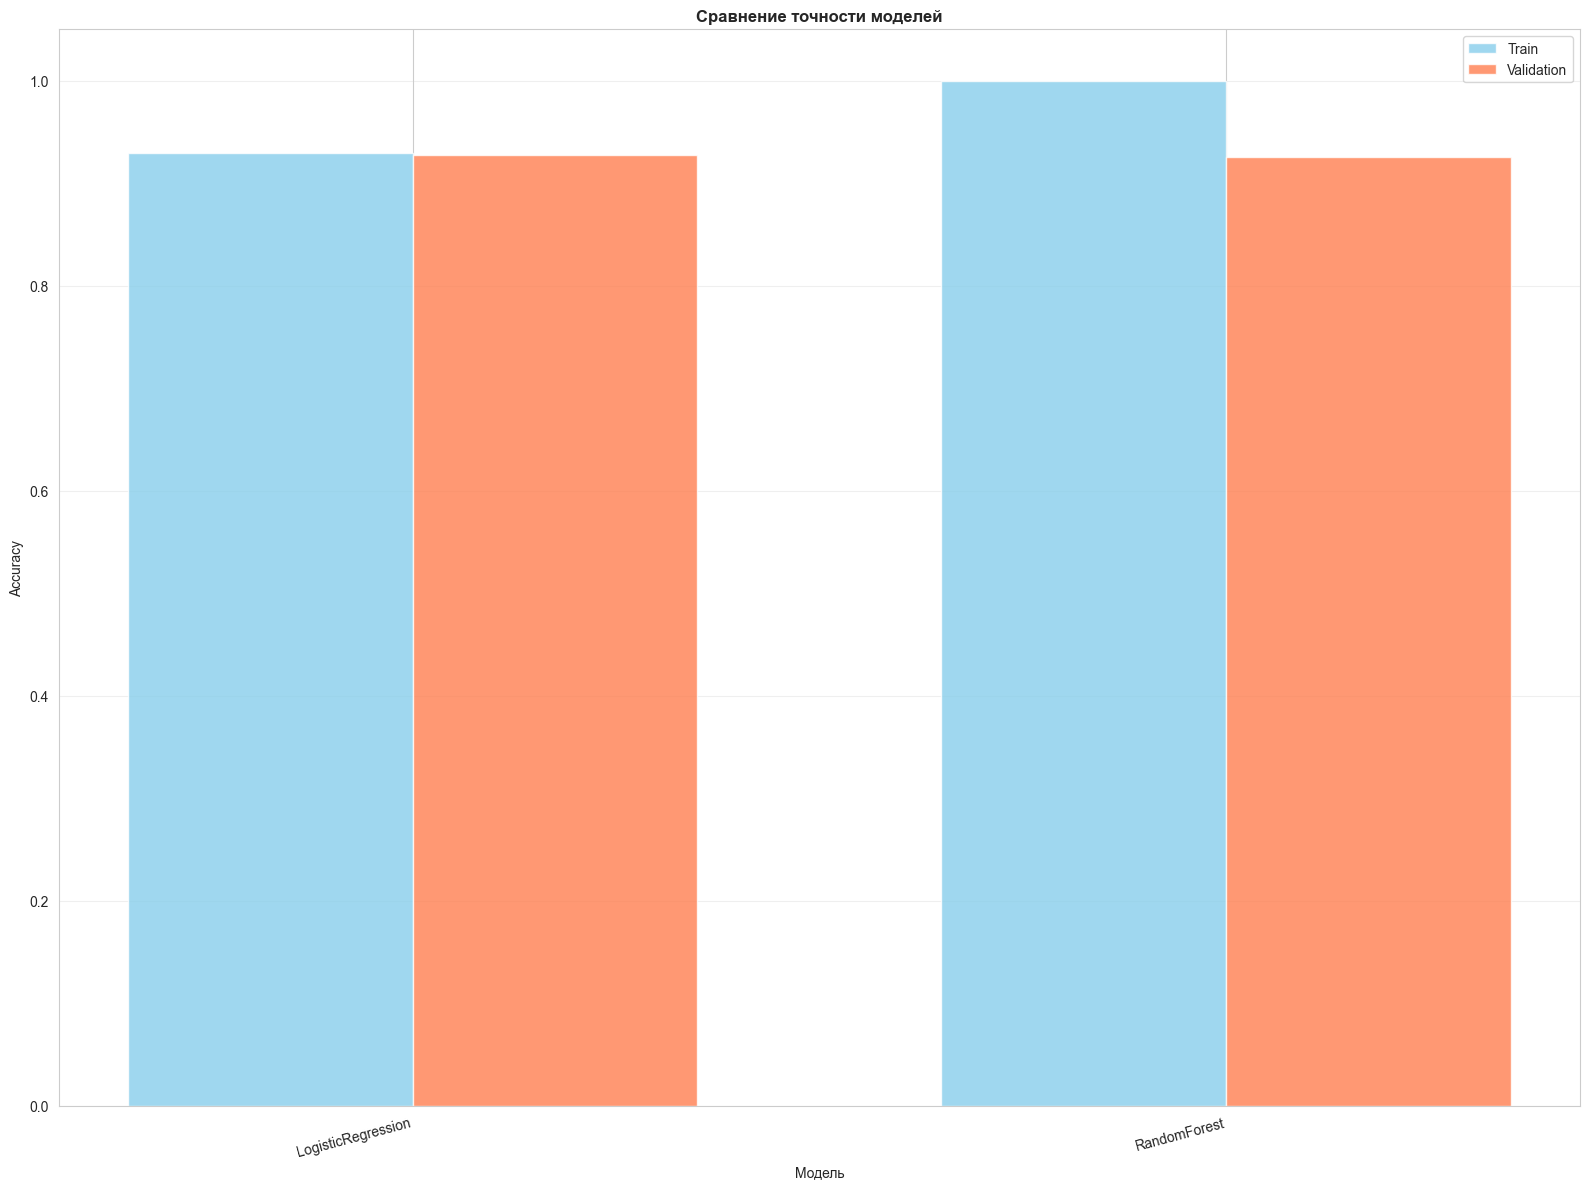

In [115]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
val_accs = [results[name]['val_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax.bar(x + width/2, val_accs, width, label='Validation', alpha=0.8, color='coral')
ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение точности моделей', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/models_scores_w2v.png', dpi=300)

# TF-IDF

## Разделим данные

In [116]:
X = train_data_tf['combined_text']
y = train_data_tf['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [117]:
print(f"\nРаспределение классов в train:")
print(y_train.value_counts())
print(f"\nРаспределение классов в validation:")
print(y_val.value_counts())


Распределение классов в train:
label
0    1777
1    1749
Name: count, dtype: int64

Распределение классов в validation:
label
0    444
1    438
Name: count, dtype: int64


## Векторизация

In [118]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),  
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%")

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.97%


## Обучим 3 модели и в последствии выберем лучшую
---
* Logistic Regression
* Naive Bayes
* Random Forest

In [119]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

In [120]:
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 2, 5],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    },
    'Naive Bayes': {
        'alpha': [0.01, 0.1, 0.5, 1.0]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced']
    }
}

In [121]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name],
                        cv=3, scoring='f1_weighted',
                        n_jobs=-1, verbose=1)
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_val, y_val_pred,
        target_names=['Фейк (disagree)', 'Реальная (agree)'],
        digits=4
    ))

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

    with open(f"models/{model_name}_model_tf.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_tuned.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9983
Val Accuracy:   0.9603
Val F1-Score:   0.9603

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9455    0.9775    0.9612       444
Реальная (agree)     0.9764    0.9429    0.9593       438

        accuracy                         0.9603       882
       macro avg     0.9609    0.9602    0.9603       882
    weighted avg     0.9608    0.9603    0.9603       882


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 1.0}
Train Accuracy: 0.9606
Val Accuracy:   0.9365
Val F1-Score:   0.9364

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9145    0.9640    0.9386       444
Ре

## Проверим на метриках

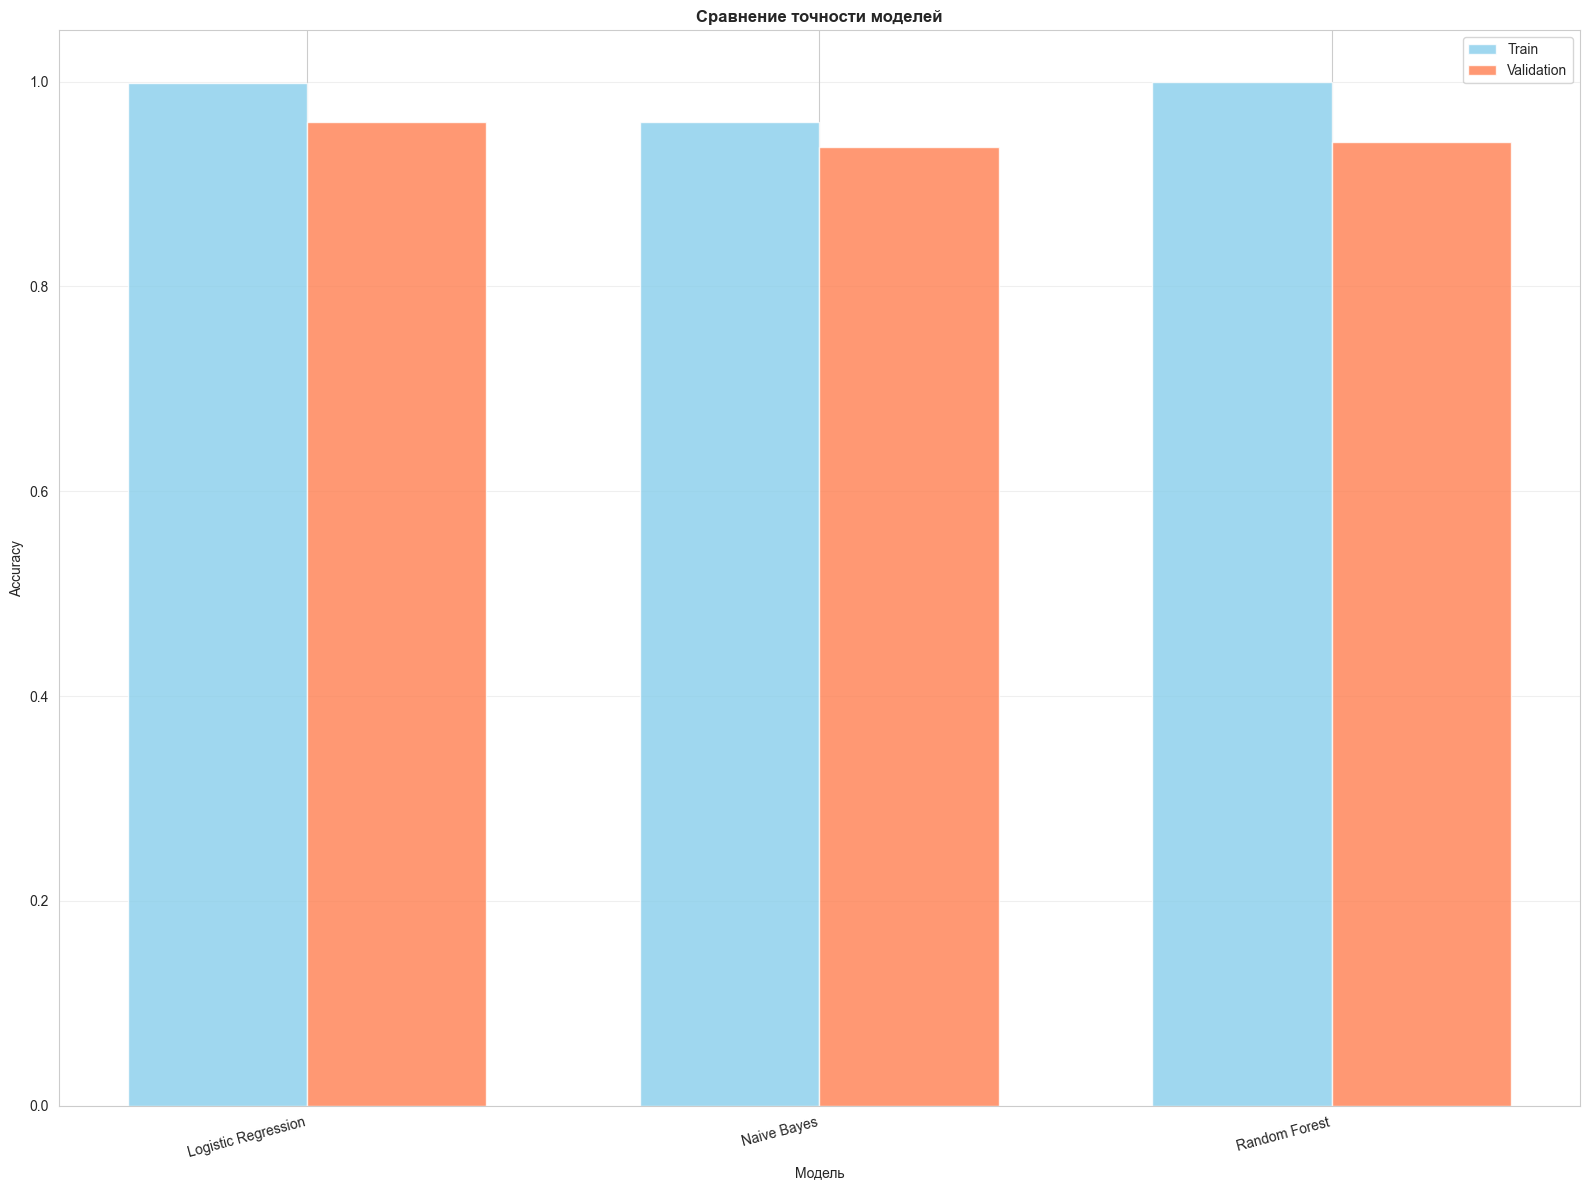

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
val_accs = [results[name]['val_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax.bar(x + width/2, val_accs, width, label='Validation', alpha=0.8, color='coral')
ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение точности моделей', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/models_scores.png', dpi=300)


In [123]:
train_data['text_length'] = train_data['combined_text'].str.split().str.len()

train_data_tf = train_data

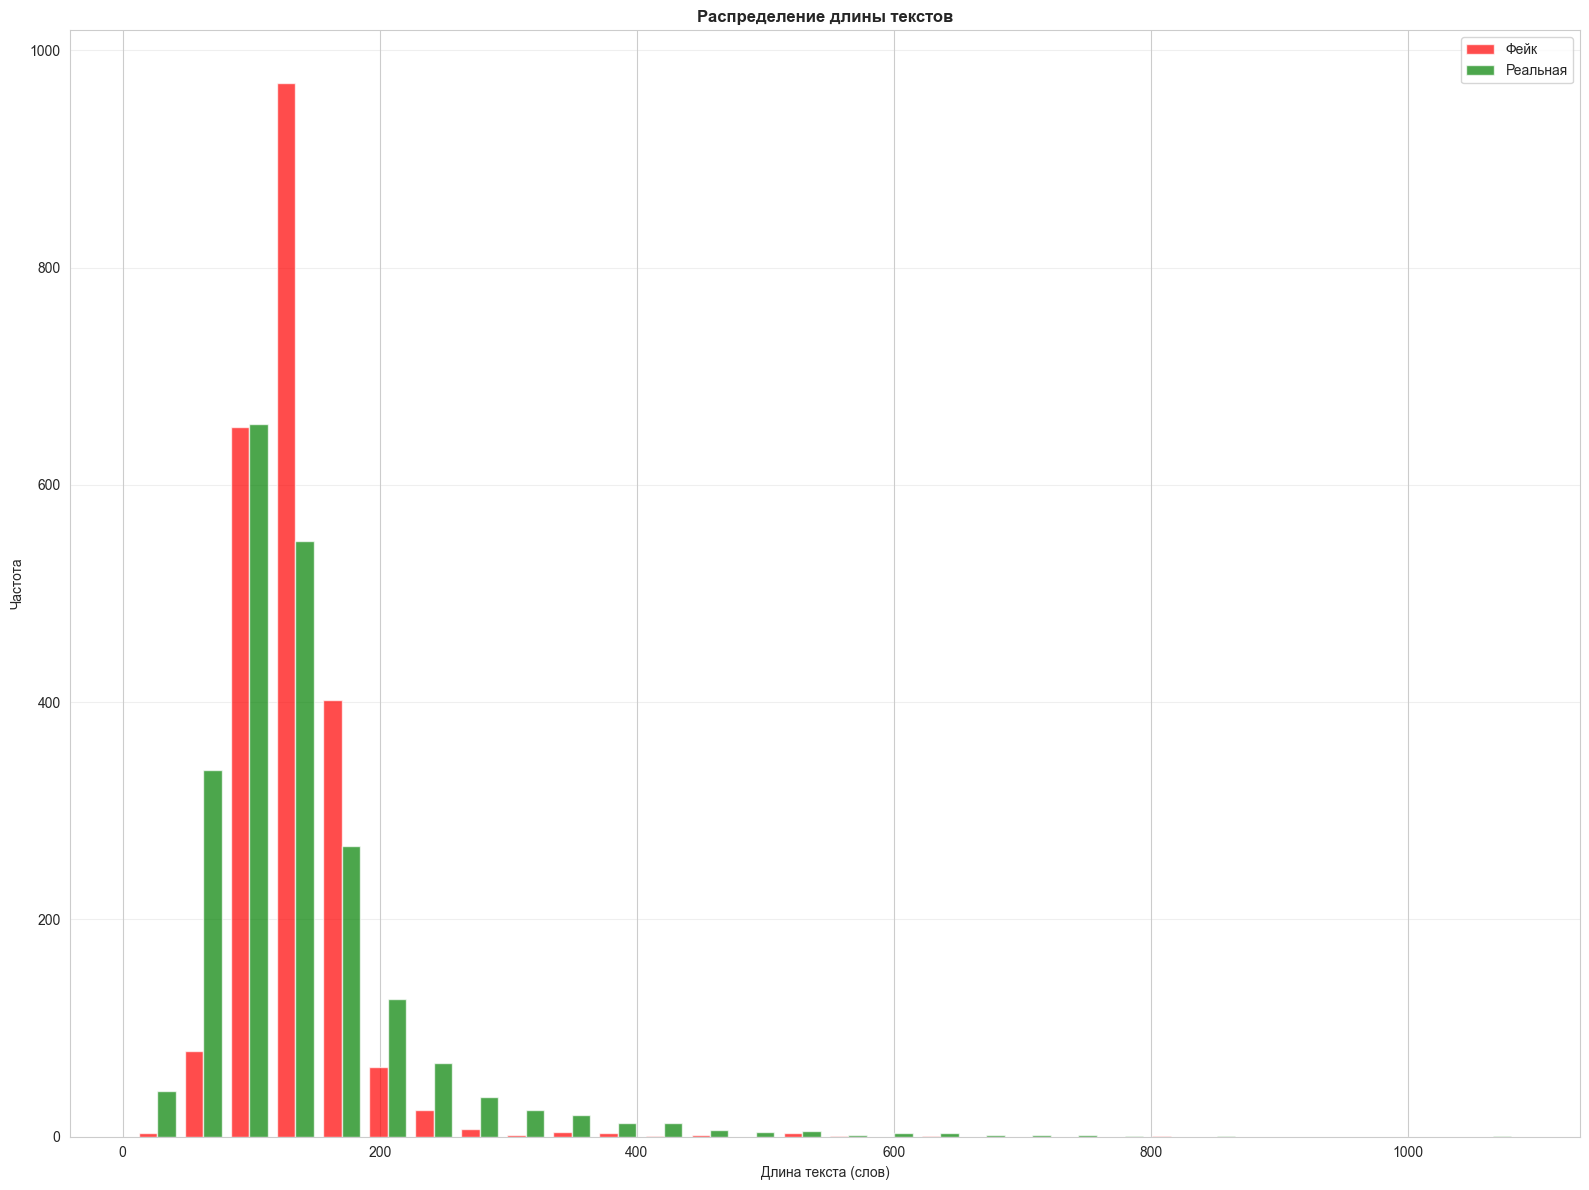

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

ax.hist(
    [train_data_tf[train_data_tf['label']==0]['text_length'],
     train_data_tf[train_data_tf['label']==1]['text_length']],
    bins=30, label=['Фейк', 'Реальная'], alpha=0.7, color=['red', 'green']
)
ax.set_xlabel('Длина текста (слов)')
ax.set_ylabel('Частота')
ax.set_title('Распределение длины текстов', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/text_lenght.png', dpi=300)

## Сохраним модели

In [125]:
# for name, info in results.items():
#     model = info['models']
#     filename = f'./models/{name}_model_tf.pkl'
#     with open(filename, 'wb') as f:
#         pickle.dump(model, f)
#     print(f"Модель {name} сохранена в {filename}")

# Также сохраняем векторизатор и лейблы (общие для всех моделей)
with open('./models/tfidf_vectorizer_tf.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('./models/label_mapping_tf.pkl', 'wb') as f:
    pickle.dump(label_mapping, f)


In [126]:
# from pathlib import Path

# # Формируем словарь метрик
# metrics = {
#     model_name: {
#         "val_acc": results[model_name]["val_acc"]
#     }
#     for model_name in results
# }

# # Создаём каталог, если его нет
# Path("results/metrics").mkdir(parents=True, exist_ok=True)

# # Сохраняем метрики в JSON
# with open("results/metrics/metrics.json", "w", encoding="utf-8") as f:
#     json.dump(metrics, f, ensure_ascii=False, indent=2)

# print("Метрики сохранены в results/metrics/metrics.json")


# TF-IDF на английском датасете (Обработка датасета выше)

In [127]:
sentences = [text.split() for text in eng_data['body_clean']] + [text.split() for text in eng_data['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

In [128]:
eng_data['text_length'] = eng_data['combined_text'].str.split().str.len()
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean,combined_text,text_length
9834,FANTASTIC! TRUMP’S 7 POINT PLAN To Reform Heal...,"Since March of 2010, the American people have ...",0,fantastic trump point plan reform healthcare b...,since march american people suffer incredible ...,fantastic trump point plan reform healthcare b...,347
12538,Trump's tweet on London train bombing just spe...,LONDON (Reuters) - Britain s interior minister...,1,trump tweet london train bombing speculation m...,london reuters britain interior minister said ...,trump tweet london train bombing speculation m...,64
24188,Why Has Donald Trump Abandoned the Foreign Pol...,21st Century Wire says President Trump is drif...,0,donald trump abandoned foreign policy election,century wire says president trump drifting neo...,donald trump abandoned foreign policy election...,223


In [129]:
X = eng_data['combined_text']
y = eng_data['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [130]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),  
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%")

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.05%


In [131]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name],
                        cv=3, scoring='f1_weighted',
                        n_jobs=-1, verbose=1)
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_val, y_val_pred,
        target_names=['Фейк (disagree)', 'Реальная (agree)'],
        digits=4
    ))

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

    with open(f"models/{model_name}_model_tf_eng.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_eng.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'liblinear'}
Train Accuracy: 0.9992
Val Accuracy:   0.9968
Val F1-Score:   0.9968

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9994    0.9955    0.9974      3328
Реальная (agree)     0.9927    0.9990    0.9958      2029

        accuracy                         0.9968      5357
       macro avg     0.9960    0.9973    0.9966      5357
    weighted avg     0.9968    0.9968    0.9968      5357


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 0.01}
Train Accuracy: 0.9861
Val Accuracy:   0.9854
Val F1-Score:   0.9855

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9921    0.9844    0.9882      3328
Реа

In [132]:
with open('./models/tfidf_vectorizer_tf_eng.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('./models/label_mapping_tf_eng.pkl', 'wb') as f:
    pickle.dump(label_mapping, f)